# SHAP vs Partial Dependence Plots, Heart Disease Prediction
**Felix Mrak, s1145815**

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import classification_report

## Data

In [50]:
df = pd.read_csv("data/heart.csv")
print(f"{df.shape[0]} patients, {df.shape[1] - 1} features")
print(f"Target distribution: {df['target'].value_counts().to_dict()}")
df.head()

1025 patients, 13 features
Target distribution: {1: 526, 0: 499}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [51]:
df.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


## Train model

In [52]:
X = df.drop("target", axis=1).astype(float)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



## SHAP

In [53]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

### Waterfall (single patient explanation)

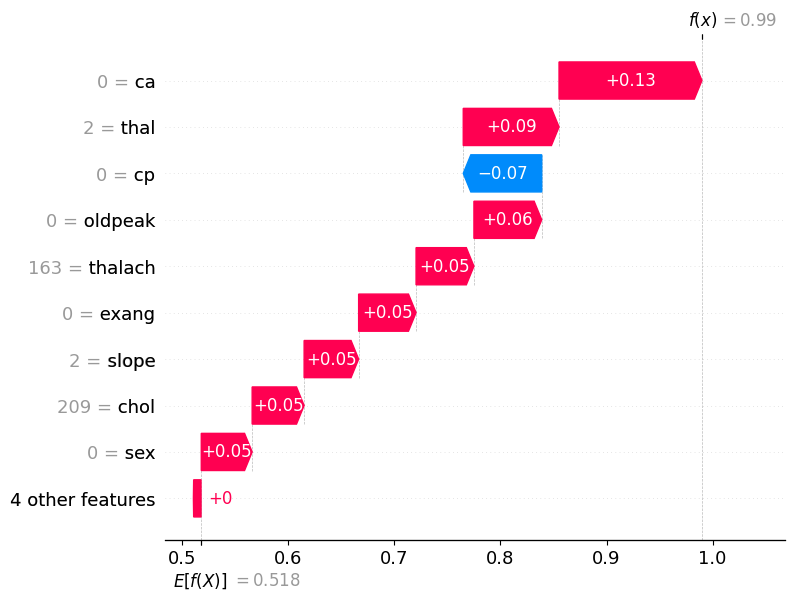

In [54]:
# Patient 0 (is in test set and has disease class 1)
shap.plots.waterfall(shap_values[0, :, 1], max_display=10)

### Beeswarm (all patients)

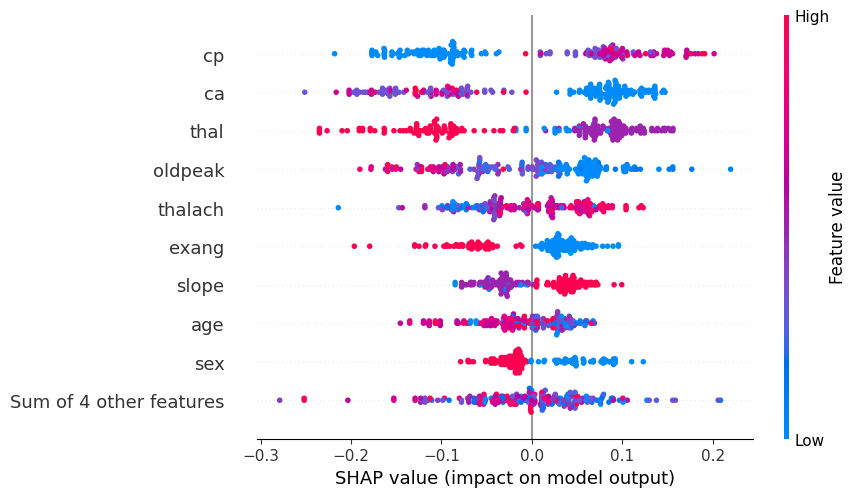

In [55]:
shap.plots.beeswarm(shap_values[:, :, 1])

### SHAP bar plot (mean feature importance)

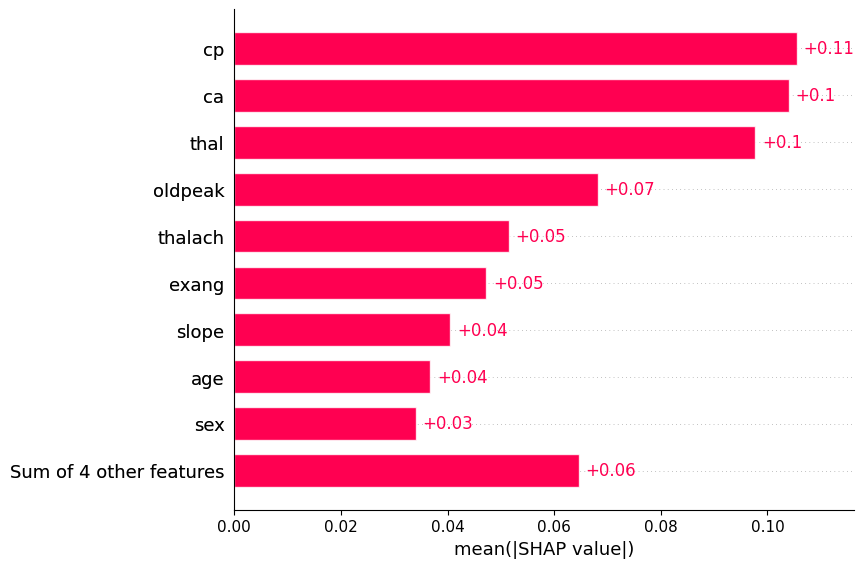

In [56]:
shap.plots.bar(shap_values[:, :, 1])

### SHAP dependence (sex)

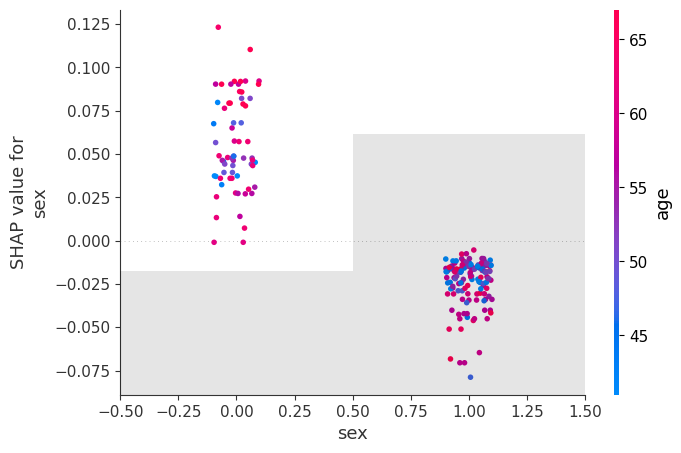

In [57]:
shap.plots.scatter(shap_values[:, "sex", 1], color=shap_values[:, "age", 1])

## Partial Dependence Plots

### 1-D PDPs

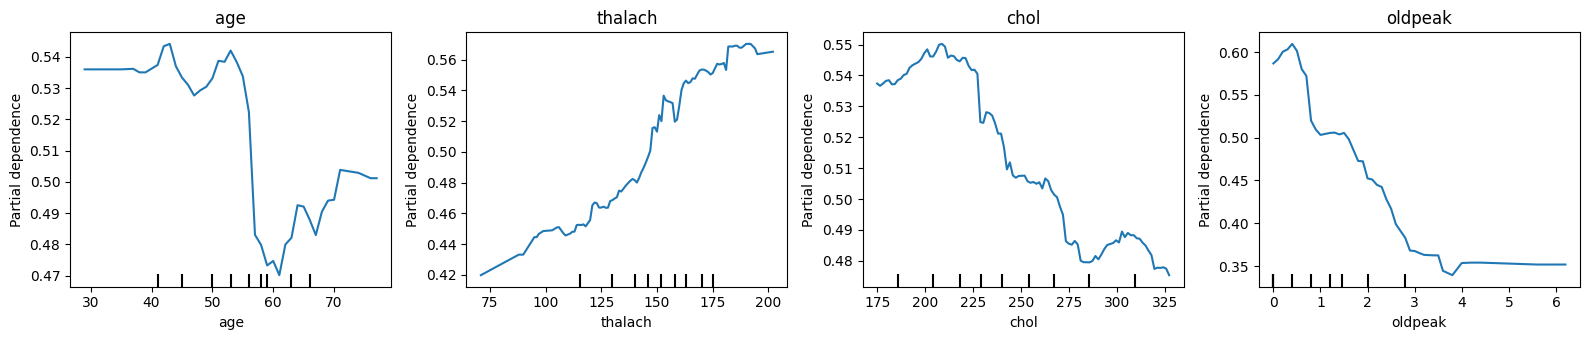

In [58]:
features = ["age", "thalach", "chol", "oldpeak"]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for i, feat in enumerate(features):
    PartialDependenceDisplay.from_estimator(
        model, X_train, [feat], ax=axes[i],
        kind="average", target=1
    )
    axes[i].set_title(feat)

plt.tight_layout()
plt.show()

### 2-D PDP (age × sex interaction)

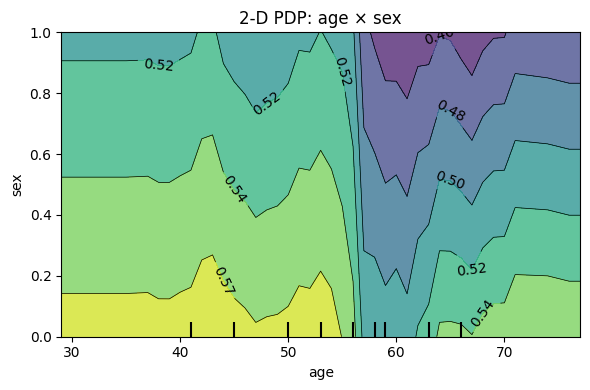

In [59]:
fig, ax = plt.subplots(figsize=(6, 4))
PartialDependenceDisplay.from_estimator(
    model, X_train, [("age", "sex")], ax=ax, target=1
)
ax.set_title("2-D PDP: age × sex")
plt.tight_layout()
plt.show()

### PDP + ICE (age)

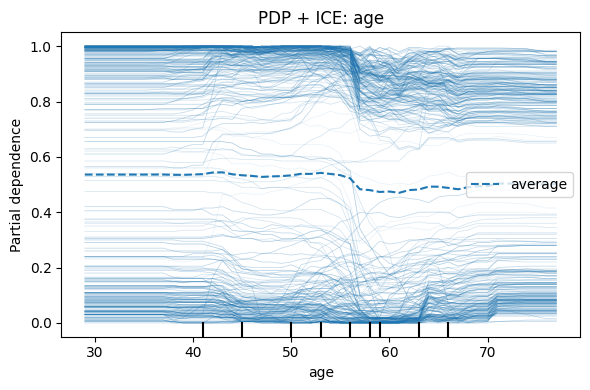

In [60]:
fig, ax = plt.subplots(figsize=(6, 4))
PartialDependenceDisplay.from_estimator(
    model, X_train, ["age"], ax=ax,
    kind="both", ice_lines_kw={"alpha": 0.1}, target=1
)
ax.set_title("PDP + ICE: age")
plt.tight_layout()
plt.show()